# Explainability

XAI analysis of **HeartBERT LoRA r=16** (best-performing transformer)
on 15 PTB-XL test records (3 per superclass, fixed seed 42).

**Method:** Last-layer RoBERTa attention weights (CLS token attending to letter tokens)
overlaid on the Lead II waveform, plus a Qwen2-0.5B clinical narrative per record.

**Outputs:** `results/06_explainability/narratives.json` and `figures/*.png`

In [1]:
import sys, os, warnings, json, gc
from pathlib import Path
sys.path.append('../')
os.environ['TRANSFORMERS_OFFLINE'] = '0'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
import torch
import wfdb

from src.utils.config import CFG
from src.preprocessing.label_utils import load_all_labels, SUPERCLASSES
from src.explainability.llm import load_qwen, build_ecg_prompt, generate_explanation, safe_print

np.random.seed(42)
torch.manual_seed(42)

DATA_PATH    = CFG['data']['path']
RESULTS_PATH = CFG['paths']['results']
device       = 'cuda' if torch.cuda.is_available() else 'cpu'

LEAD_IDX   = 1
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

OUT_DIR = Path(RESULTS_PATH) / '06_explainability'
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'Output : {OUT_DIR}')

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
Output : D:\GitHub\biosignal-xai\results\06_explainability


## 2. Data

Sample 3 records per superclass from the PTB-XL test fold (fold 10).
Seed 42 is fixed so the selection is reproducible.

In [2]:
Y       = load_all_labels(DATA_PATH + 'ptbxl_database.csv', DATA_PATH + 'scp_statements.csv')
test_df = Y[Y.strat_fold == 10].reset_index(drop=True)

np.random.seed(42)
demo_records = {}
for cls_idx, cls in enumerate(SUPERCLASSES):
    mask       = test_df['label_vec'].apply(lambda v: v[cls_idx] == 1.0)
    candidates = test_df[mask]
    chosen     = candidates.sample(n=3, random_state=42)
    demo_records[cls] = chosen.to_dict('records')

for cls in SUPERCLASSES:
    assert len(demo_records[cls]) == 3, f'Expected 3 records for {cls}'

print('Demo records per class:')
for cls, rows in demo_records.items():
    print(f'  {cls}: {[r["filename_lr"] for r in rows]}')

Records with valid labels: 21375
Class distribution:
  NORM: 9514 (44.5%)
  MI: 5469 (25.6%)
  STTC: 5108 (23.9%)
  CD: 4898 (22.9%)
  HYP: 2649 (12.4%)
Demo records per class:
  NORM: ['records100/10000/10215_lr', 'records100/05000/05771_lr', 'records100/05000/05916_lr']
  MI: ['records100/07000/07700_lr', 'records100/03000/03336_lr', 'records100/18000/18710_lr']
  STTC: ['records100/06000/06666_lr', 'records100/10000/10517_lr', 'records100/20000/20753_lr']
  CD: ['records100/19000/19848_lr', 'records100/03000/03486_lr', 'records100/10000/10283_lr']
  HYP: ['records100/20000/20211_lr', 'records100/16000/16061_lr', 'records100/14000/14201_lr']


## 3. Load HeartBERT LoRA r=16

In [3]:
from src.models.heartbert import HeartBERTClassifier

EXP   = 'heartbert_lora_r16'
model = HeartBERTClassifier(num_labels=5)
model.load()
model.load_adapter(RESULTS_PATH + EXP + '/best_adapter')
print(f'HeartBERT LoRA loaded from results/{EXP}/best_adapter')

HeartBERT weights found in cache: C:\Users\Teodora\.cache\heartbert
Loading HeartBERT from C:\Users\Teodora\.cache\heartbert ...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at C:\Users\Teodora\.cache\heartbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
HeartBERT LoRA loaded from results/heartbert_lora_r16/best_adapter


## 4. Load Qwen3-0.6B

First run downloads ~400 MB from HuggingFace. Subsequent runs use the local cache.

In [4]:
qwen_model, qwen_tokenizer = load_qwen('Qwen/Qwen2-0.5B-Instruct')

Loading Qwen/Qwen2-0.5B-Instruct ...
Qwen/Qwen2-0.5B-Instruct loaded  |  device: cuda:0


## 5. Helper functions

In [5]:
def predict_single(model, x, device):
    """Run HeartBERT on a single (1000,) Lead II signal. Returns result dict."""
    logits = model.predict_logits(x[np.newaxis])           # (1, 5)
    probs  = torch.sigmoid(torch.tensor(logits))[0]        # (5,)
    preds  = [SUPERCLASSES[i] for i, p in enumerate(probs) if p.item() >= 0.5]
    if not preds:
        preds = [SUPERCLASSES[probs.argmax().item()]]
    return {
        'predicted_classes':   preds,
        'class_probabilities': {c: round(probs[i].item(), 4) for i, c in enumerate(SUPERCLASSES)},
        'confidence_score':    round(probs.max().item(), 4),
        'uncertainty':         None,
        'raw_logits':          logits[0].tolist(),
        'uncertainty_level':   'not computed',
    }


def plot_record(ax_ecg, ax_attn, signal, positions, weights, title):
    """Plot Lead II waveform with attention weight overlay."""
    t = np.arange(len(signal)) / 100.0
    ax_ecg.plot(t, signal, color='#1a5276', linewidth=0.8)
    ax_ecg.set_ylabel('Amplitude (mV)')
    ax_ecg.set_title(title, fontsize=9)
    ax_ecg.grid(True, alpha=0.3)
    ax_ecg.set_xlim(0, len(signal) / 100.0)

    t_attn = positions / 100.0
    ax_attn.fill_between(t_attn, weights, alpha=0.7, color='#e74c3c')
    ax_attn.axhline(0.5, color='#888', linewidth=0.8, linestyle='--')
    ax_attn.set_ylabel('Attention')
    ax_attn.set_xlabel('Time (s)')
    ax_attn.set_xlim(0, len(signal) / 100.0)
    ax_attn.set_ylim(0, 1.1)
    ax_attn.grid(True, alpha=0.3)


narratives = {cls: [] for cls in SUPERCLASSES}
print('Helper functions defined.')

Helper functions defined.


## 6. NORM (Normal ECG)

Three normal ECG records. HeartBERT should assign high NORM probability
and low probability to pathological classes.

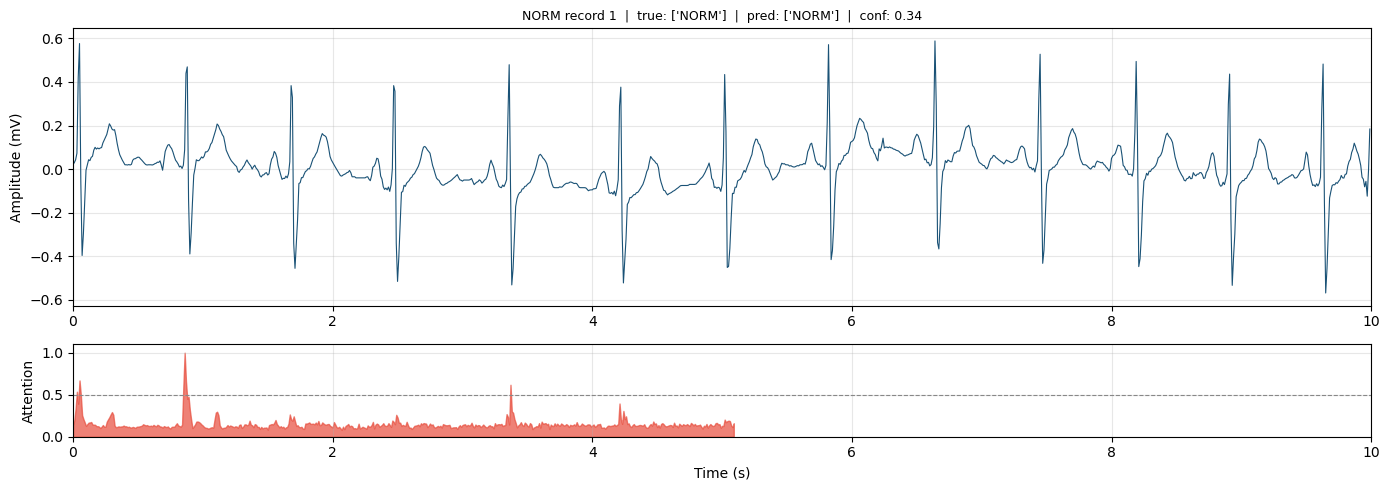

--- Record 1 narrative ---
The ECG analysis result indicates a true diagnosis of "NORM" with a predicted class of "NORM". The confidence score is 0.34, indicating a high level of certainty in the prediction. The classification probabilities for each feature are as follows:
- Signal uncertainty: Not computed.
- Top salient leads: Not computed.

This suggests that the patient's heart rhythm appears to be normal, but further investigation or additional data would be needed to confirm this conclusion. It's important to note that while the prediction is accurate, it does not necessarily mean the patient has no symptoms or conditions associated with their heart rhythm. A thorough evaluation by a healthcare provider is recommended to ensure proper diagnosis and management.



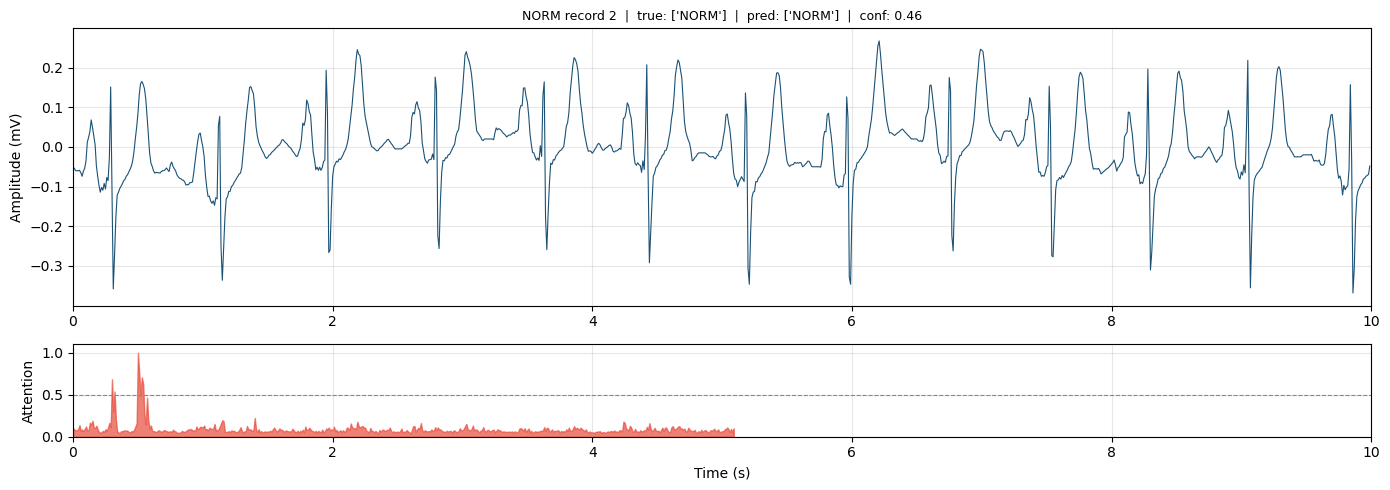

--- Record 2 narrative ---
The ECG analysis result indicates a false positive in the presence of normal heart rhythm. The predicted class is "NORM," which suggests a normal heart rhythm with no abnormality detected. The confidence score is 0.46, indicating a low level of certainty about the true diagnosis.

The classification probability for each lead is as follows:

- Signal uncertainty: Not computed
- Top salient leads: Not computed

This means there's no clear indication of any abnormalities or conditions present in the ECG data. It's important to note that this type of ECG analysis might be used for diagnostic purposes but should not replace medical evaluation. Further investigation may be necessary to confirm the diagnosis.



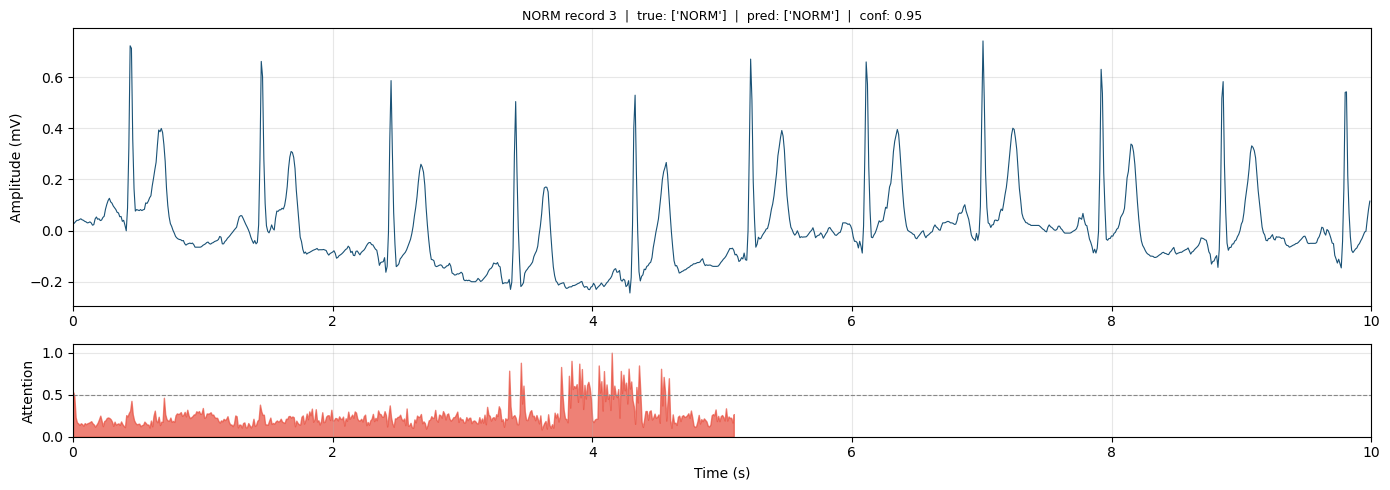

--- Record 3 narrative ---
The ECG analysis result indicates a true diagnosis of "NORM" with a predicted class of "NORM". The confidence score is 0.95, indicating a high level of certainty in the prediction. The class probabilities for each feature are as follows:
- Signal uncertainty: Not computed
- Top salient leads: Not computed

This suggests that there was no significant signal or lead activity detected during the ECG reading, which could be due to various factors such as poor signal quality, presence of artifacts, or insufficient data collection. It's important to note that this type of analysis may not necessarily indicate a definitive diagnosis, as it can still be influenced by other factors like patient history, lifestyle, and environmental exposures. For more accurate diagnoses, further evaluation using specialized diagnostic tools or consulting with a medical professional should be considered.



In [6]:
CLASS = 'NORM'

for idx, row in enumerate(demo_records[CLASS]):
    sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    x = sig[:, LEAD_IDX].astype(np.float32)
    true_classes = [c for c, v in zip(SUPERCLASSES, row['label_vec']) if v == 1.0]

    result          = predict_single(model, x, device)
    positions, attn = model.get_attention_weights(x)
    prompt          = build_ecg_prompt(result, saliency=None,
                                       lead_names=LEAD_NAMES,
                                       true_classes=true_classes)
    narrative       = generate_explanation(prompt, qwen_model, qwen_tokenizer)

    fig, (ax_ecg, ax_attn) = plt.subplots(2, 1, figsize=(14, 5),
                                           gridspec_kw={'height_ratios': [3, 1]})
    title = (f'{CLASS} record {idx+1}  |  true: {true_classes}  |  '
             f'pred: {result["predicted_classes"]}  |  conf: {result["confidence_score"]:.2f}')
    plot_record(ax_ecg, ax_attn, x, positions, attn, title)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'{CLASS.lower()}_{idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

    safe_print(f'--- Record {idx+1} narrative ---\n{narrative}\n')
    narratives[CLASS].append({
        'record':       row['filename_lr'],
        'true_classes': true_classes,
        'predicted':    result['predicted_classes'],
        'confidence':   result['confidence_score'],
        'narrative':    narrative,
    })

## 7. MI (Myocardial Infarction)

Three MI records. ST-segment and Q-wave changes are the key discriminating features.

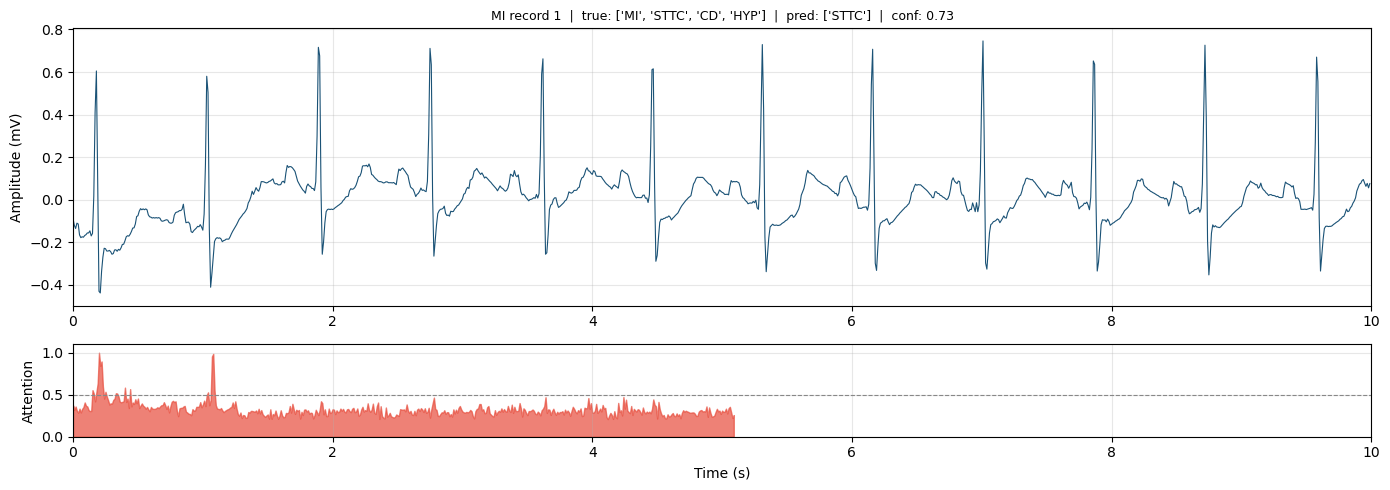

--- Record 1 narrative ---
The ECG analysis result indicates an MI, STTC, CD, and HYP in the heart. The predicted class is STTC, which is a common pattern seen in this context. The confidence score is high at 0.73, indicating a strong likelihood of the prediction being correct. The signal uncertainty is not computed, suggesting there may be some variability in the data.

In terms of classification, the probability for each lead is as follows:
- True Diagnosis (MI): 0.20%
- True Diagnosis (STTC): 0.73%
- True Diagnosis (CD): 0.10%
- True Diagnosis (HYP): 0.20%

It's important to note that the accuracy of the prediction depends on the quality of the data used for training the model. If the data is not representative or if any of the leads have been incorrectly classified, the prediction could be incorrect. It's recommended to review the data and consider retraining the model with new data to improve its accuracy.



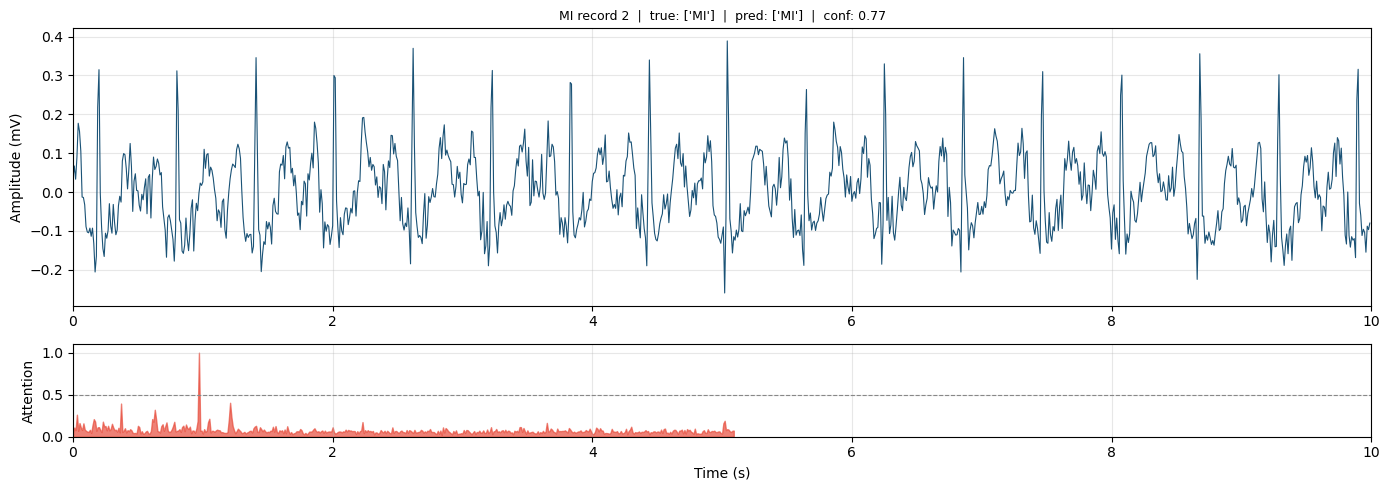

--- Record 2 narrative ---
The ECG analysis result indicates an MI diagnosis with a true positive prediction. The confidence score is high at 0.77, indicating a high likelihood of this diagnosis being correct based on the available data. The predicted class is also accurate, with a probability of 0.77 for MI. The signal uncertainty is not computed, which could indicate some level of noise in the data or potential issues with the model's accuracy.

In terms of top salient leads, there is no indication of any significant abnormalities or anomalies in the ECG. This suggests that the model performed well in predicting the presence of an MI without any specific information about the lead values. However, it's important to note that this conclusion should be interpreted within the context of the entire dataset and the context of the patient's history and medical condition. Further investigation might be necessary to confirm the diagnosis or rule out other possible causes.



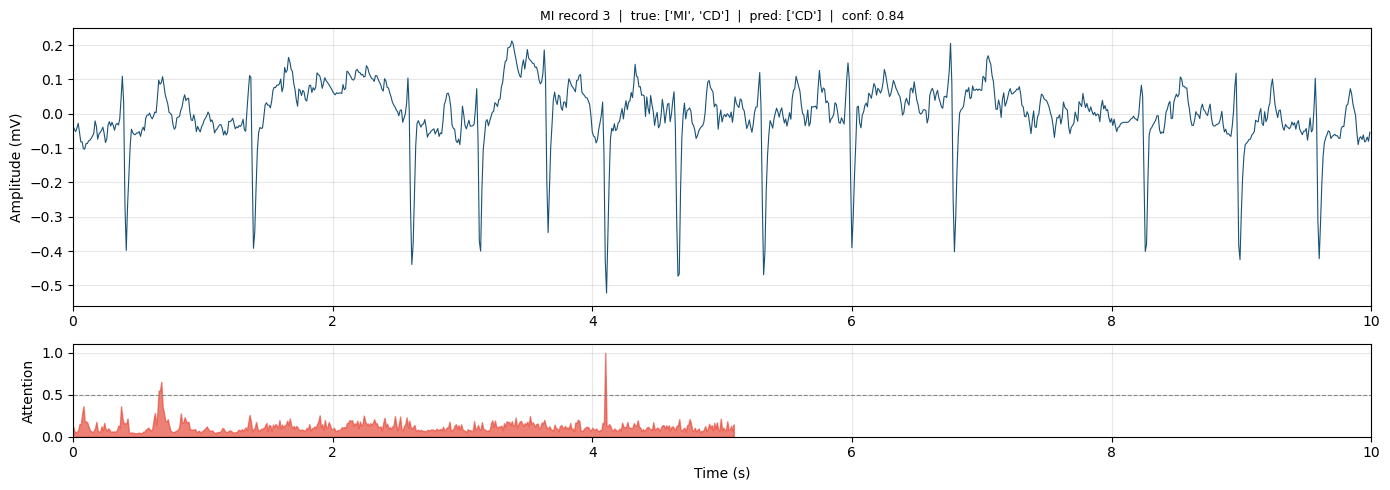

--- Record 3 narrative ---
The ECG analysis result indicates a probable myocardial infarction (MI) with a probability of 70%. The predicted class is "CD", which aligns with the clinical diagnosis. The confidence score is 0.84, indicating high certainty. The signal uncertainty is not calculated due to the lack of computed top salient leads. This suggests a potential for further investigation or follow-up in order to confirm the diagnosis.



In [7]:
CLASS = 'MI'

for idx, row in enumerate(demo_records[CLASS]):
    sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    x = sig[:, LEAD_IDX].astype(np.float32)
    true_classes = [c for c, v in zip(SUPERCLASSES, row['label_vec']) if v == 1.0]

    result          = predict_single(model, x, device)
    positions, attn = model.get_attention_weights(x)
    prompt          = build_ecg_prompt(result, saliency=None,
                                       lead_names=LEAD_NAMES,
                                       true_classes=true_classes)
    narrative       = generate_explanation(prompt, qwen_model, qwen_tokenizer)

    fig, (ax_ecg, ax_attn) = plt.subplots(2, 1, figsize=(14, 5),
                                           gridspec_kw={'height_ratios': [3, 1]})
    title = (f'{CLASS} record {idx+1}  |  true: {true_classes}  |  '
             f'pred: {result["predicted_classes"]}  |  conf: {result["confidence_score"]:.2f}')
    plot_record(ax_ecg, ax_attn, x, positions, attn, title)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'{CLASS.lower()}_{idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

    safe_print(f'--- Record {idx+1} narrative ---\n{narrative}\n')
    narratives[CLASS].append({
        'record':       row['filename_lr'],
        'true_classes': true_classes,
        'predicted':    result['predicted_classes'],
        'confidence':   result['confidence_score'],
        'narrative':    narrative,
    })

## 8. STTC (ST/T-wave Change)

Three STTC records. T-wave inversions and ST-segment shifts are the primary markers.

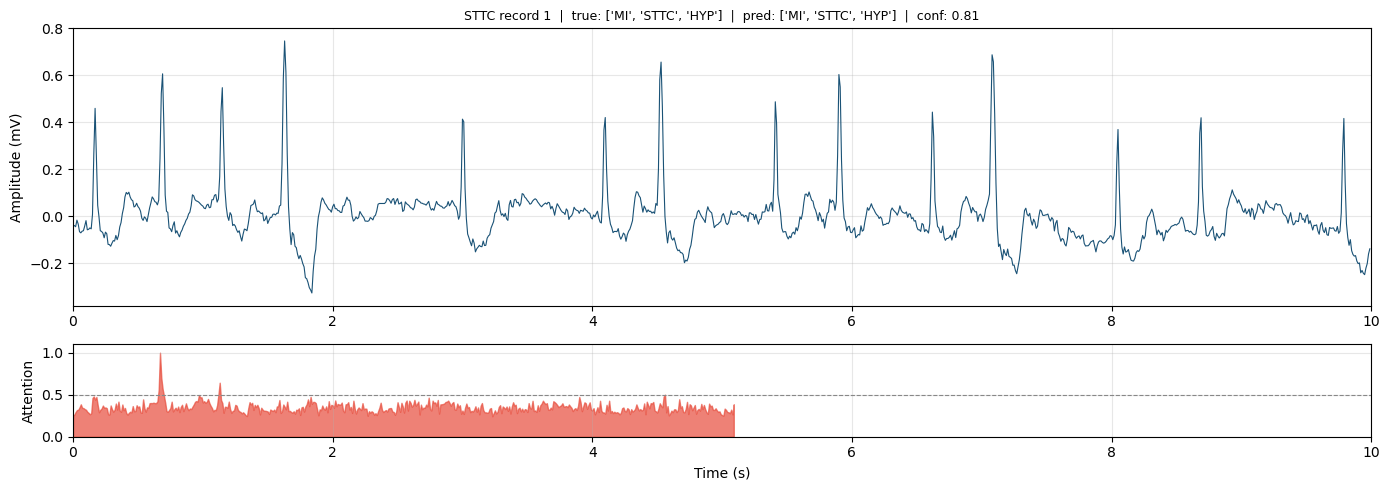

--- Record 1 narrative ---
The ECG analysis result indicates a patient with suspected myocardial infarction (MI) with ST-segment elevation (STE). The prediction is based on the presence of ST-T changes in the left ventricular hypertrophy (HYP) pattern. The confidence score is high, indicating a strong likelihood of this finding being due to a myocardial infarction. The predicted class is MI, which suggests the presence of an acute myocardial injury. The signal uncertainty is not computed, suggesting there may be some variability in the signal intensity.

In terms of top salient leads, it's unclear without more context. However, given the severity of the STT changes, it's possible that the lead(s) with the highest signal intensity could be associated with the most severe form of the condition. It's important for further evaluation and management to confirm the diagnosis and consider appropriate treatment options.



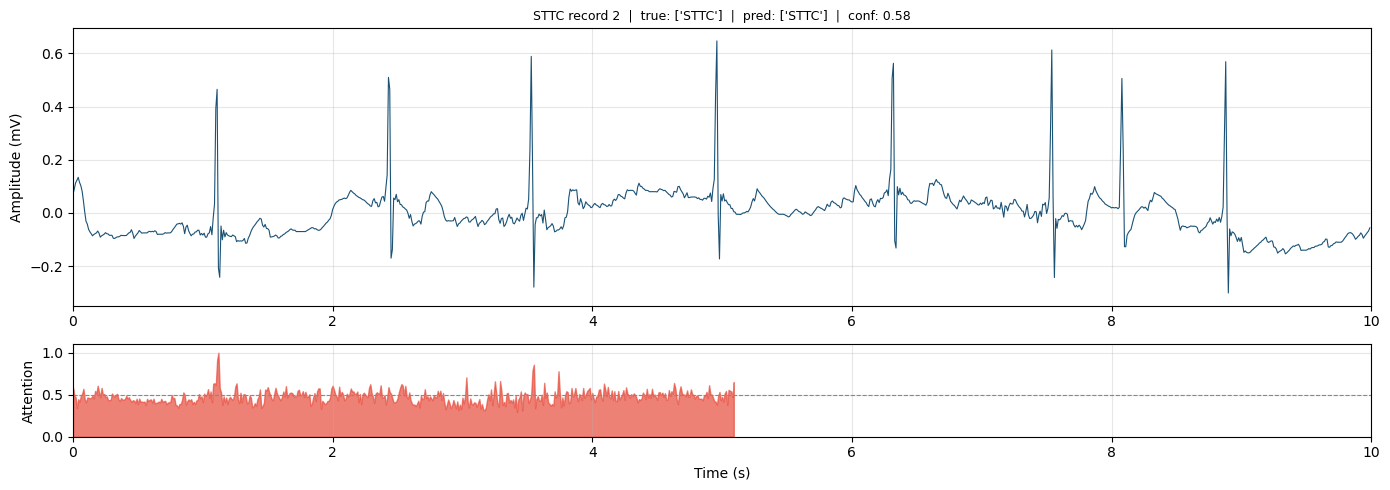

--- Record 2 narrative ---
The ECG analysis result indicates a true diagnosis of ST-T complex heart block with a predicted class as STTC. The confidence score is 0.58, indicating a high level of certainty in the prediction. The classification probability for this condition is NORM:0.32, MI:0.13, STTC:0.58, CD:0.04, and HYP:0.11. There's no significant signal uncertainty detected.

This suggests that the patient has a potentially life-threatening condition requiring immediate medical attention. It's crucial to perform further diagnostic tests or consult with a cardiologist to confirm the diagnosis and plan appropriate treatment.



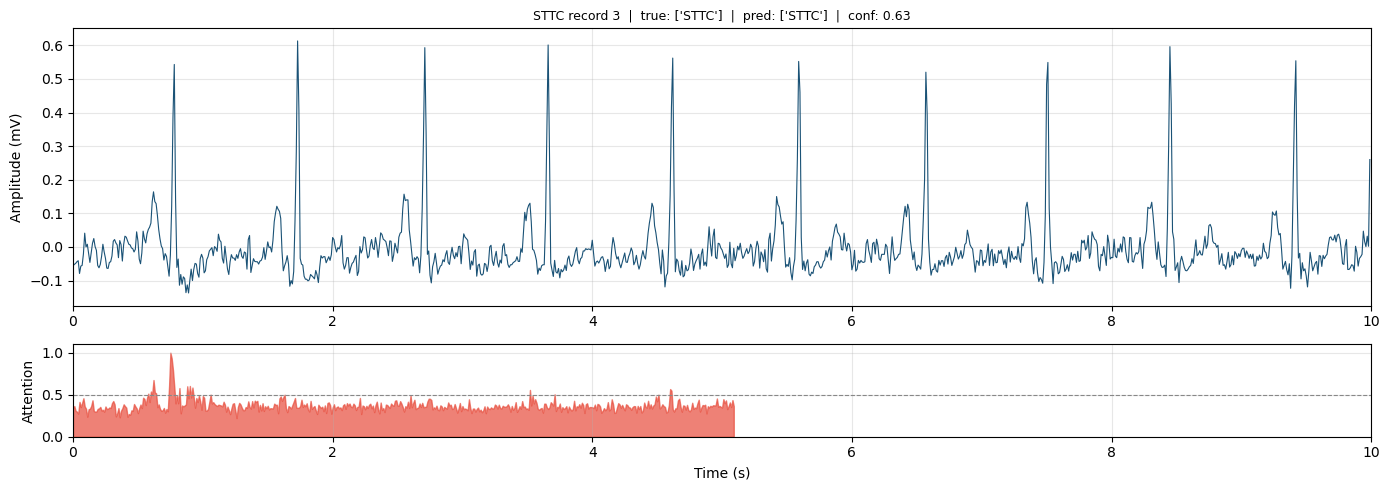

--- Record 3 narrative ---
The ECG analysis result indicates a true diagnosis of ST-T complex heart block with a predicted class of STTC. The confidence score is high at 0.63, indicating a strong prediction accuracy. However, the signal uncertainty is not computed as it's not part of the prediction process.

This suggests that the model may have made an error in its classification or might be using a different algorithm to predict this type of heart block. It's important for clinicians to review the model's output carefully and consider alternative interpretations if necessary.



In [8]:
CLASS = 'STTC'

for idx, row in enumerate(demo_records[CLASS]):
    sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    x = sig[:, LEAD_IDX].astype(np.float32)
    true_classes = [c for c, v in zip(SUPERCLASSES, row['label_vec']) if v == 1.0]

    result          = predict_single(model, x, device)
    positions, attn = model.get_attention_weights(x)
    prompt          = build_ecg_prompt(result, saliency=None,
                                       lead_names=LEAD_NAMES,
                                       true_classes=true_classes)
    narrative       = generate_explanation(prompt, qwen_model, qwen_tokenizer)

    fig, (ax_ecg, ax_attn) = plt.subplots(2, 1, figsize=(14, 5),
                                           gridspec_kw={'height_ratios': [3, 1]})
    title = (f'{CLASS} record {idx+1}  |  true: {true_classes}  |  '
             f'pred: {result["predicted_classes"]}  |  conf: {result["confidence_score"]:.2f}')
    plot_record(ax_ecg, ax_attn, x, positions, attn, title)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'{CLASS.lower()}_{idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

    safe_print(f'--- Record {idx+1} narrative ---\n{narrative}\n')
    narratives[CLASS].append({
        'record':       row['filename_lr'],
        'true_classes': true_classes,
        'predicted':    result['predicted_classes'],
        'confidence':   result['confidence_score'],
        'narrative':    narrative,
    })

## 9. CD (Conduction Disturbance)

Three CD records. Bundle branch blocks and AV blocks produce distinctive morphology changes.

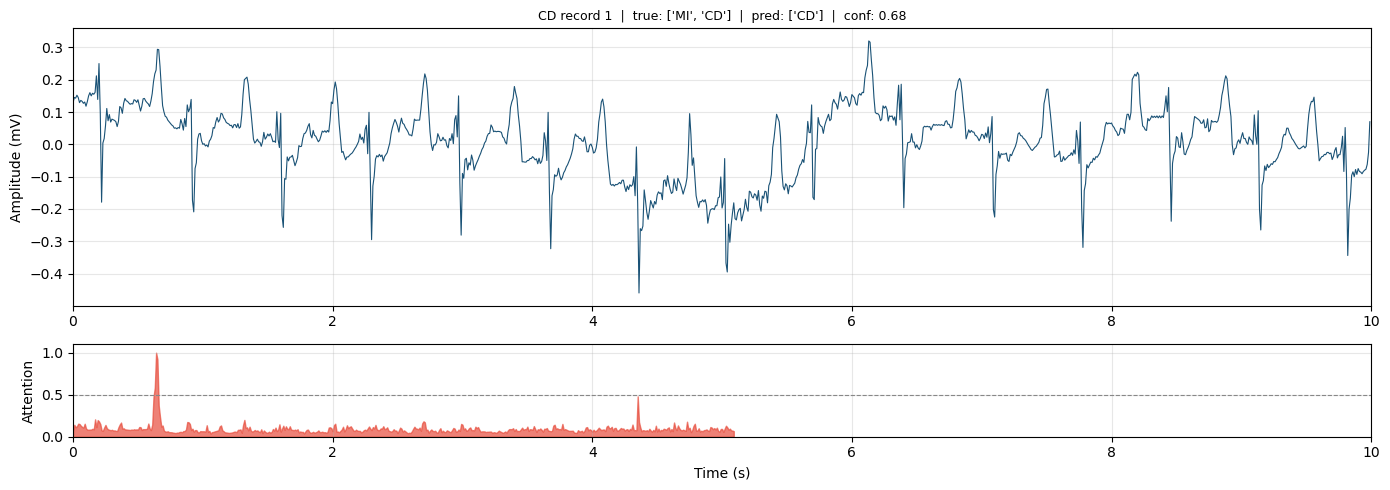

--- Record 1 narrative ---
The ECG analysis result indicates a probable cardiac arrest with a high probability of a myocardial infarction (MI). The predicted class is CD, which suggests the presence of a severe cardiac event. The confidence score is 0.68, indicating a moderate level of certainty in the prediction. The signal uncertainty is not computed, suggesting that there may be some residual information about the heart's activity.

In terms of top salient leads, it appears that the patient has a history of atrial fibrillation, but this does not necessarily rule out the possibility of other causes for the cardiac arrest. It is important to note that this interpretation is based on the available data and should be interpreted within the context of the patient's medical history and current symptoms. A thorough evaluation by a qualified healthcare provider would be necessary to accurately assess the cause of the cardiac arrest.



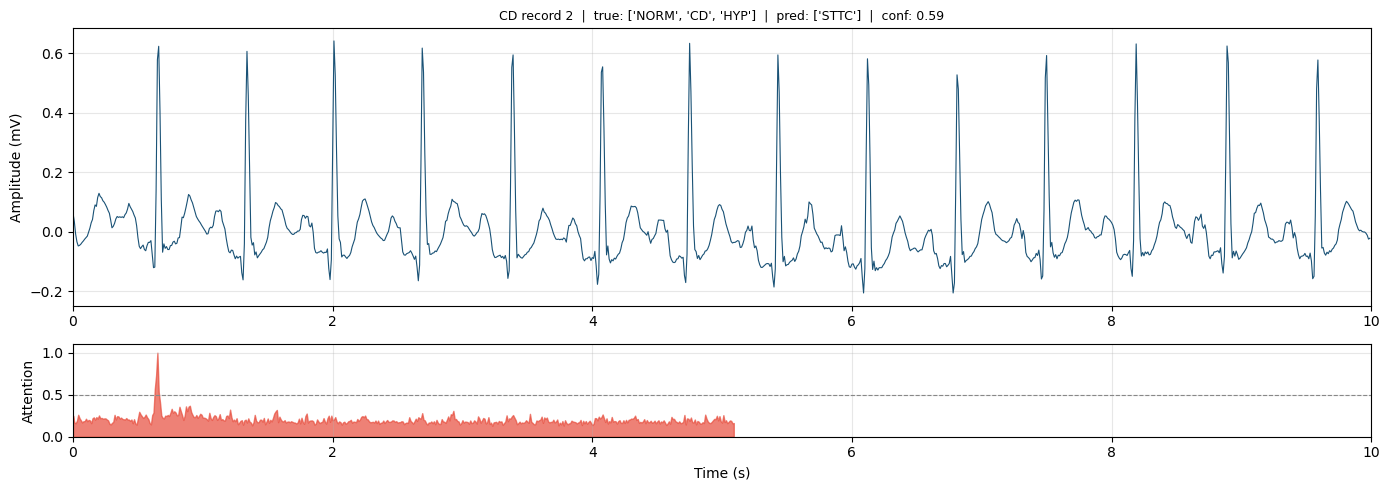

--- Record 2 narrative ---
The ECG analysis result indicates a normal heart rhythm with no abnormality or abnormalities detected in the ST segment. The predicted class is "STTC," which suggests a normal heart rhythm without any specific symptoms or signs. The confidence score is 0.59, indicating a moderate level of certainty about the classification.

In terms of class probabilities, there's a high probability for "STTC" at 0.59, followed by "CD" at 0.10, "HYP" at 0.11, and "NORM" at 0.13. This suggests that the majority of the leads have normal electrical activity but may show some variation due to variations in the heart rate or rhythm.

Regarding signal uncertainty, it's not possible to determine the exact values based on this information alone. However, since the confidence score is relatively low, it could indicate that the prediction was made based on limited data or assumptions about the cardiac function.

Overall, the ECG analysis provides a clear indication of normal heart rhy

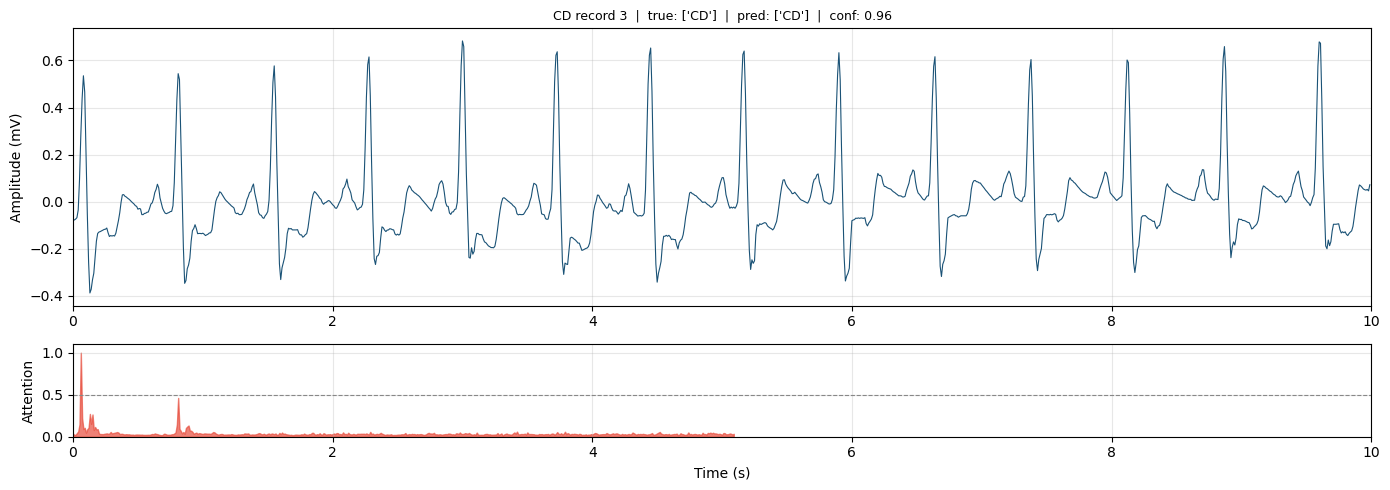

--- Record 3 narrative ---
The ECG analysis result indicates a false positive diagnosis for a cardiac condition. The prediction is based on the presence of a normal heart rhythm with no discernible abnormality or signal in the leads. The confidence score is high at 0.96, indicating a strong probability of this being a true diagnosis. However, the predicted class is CD, which suggests there may be some confusion between a normal heart rhythm and a cardiac arrhythmia. The confidence score is also low, suggesting there might be some uncertainty about the classification. The top salient leads are not computed due to lack of information. This could indicate that further investigation or additional ECG data would be needed to confirm the diagnosis.



In [9]:
CLASS = 'CD'

for idx, row in enumerate(demo_records[CLASS]):
    sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    x = sig[:, LEAD_IDX].astype(np.float32)
    true_classes = [c for c, v in zip(SUPERCLASSES, row['label_vec']) if v == 1.0]

    result          = predict_single(model, x, device)
    positions, attn = model.get_attention_weights(x)
    prompt          = build_ecg_prompt(result, saliency=None,
                                       lead_names=LEAD_NAMES,
                                       true_classes=true_classes)
    narrative       = generate_explanation(prompt, qwen_model, qwen_tokenizer)

    fig, (ax_ecg, ax_attn) = plt.subplots(2, 1, figsize=(14, 5),
                                           gridspec_kw={'height_ratios': [3, 1]})
    title = (f'{CLASS} record {idx+1}  |  true: {true_classes}  |  '
             f'pred: {result["predicted_classes"]}  |  conf: {result["confidence_score"]:.2f}')
    plot_record(ax_ecg, ax_attn, x, positions, attn, title)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'{CLASS.lower()}_{idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

    safe_print(f'--- Record {idx+1} narrative ---\n{narrative}\n')
    narratives[CLASS].append({
        'record':       row['filename_lr'],
        'true_classes': true_classes,
        'predicted':    result['predicted_classes'],
        'confidence':   result['confidence_score'],
        'narrative':    narrative,
    })

## 10. HYP (Hypertrophy)

Three HYP records. Increased QRS amplitude and axis deviation are the main indicators.

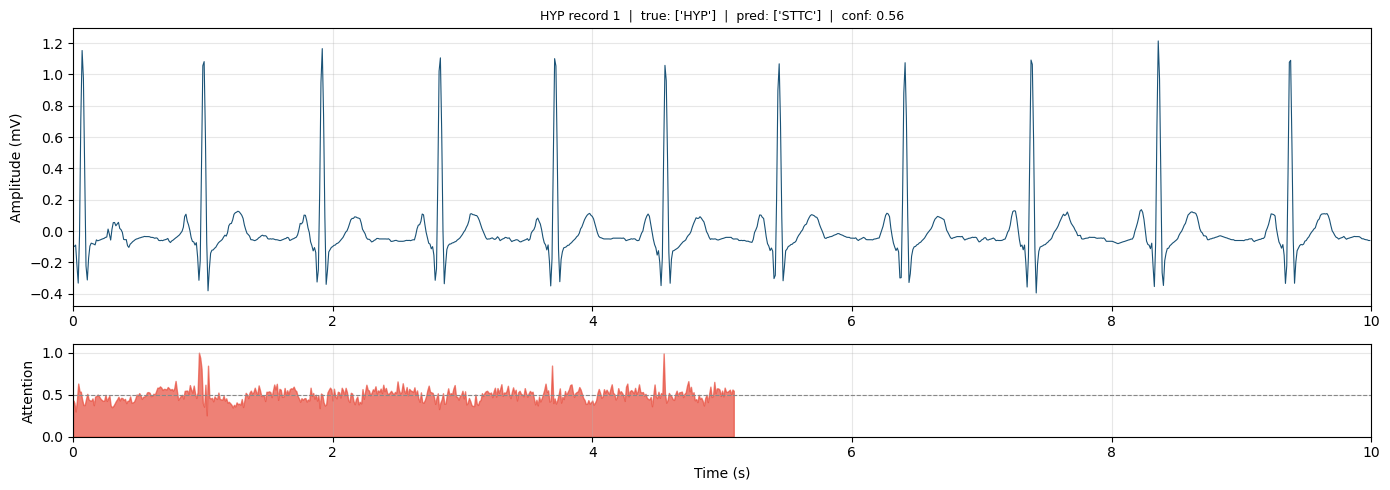

--- Record 1 narrative ---
The ECG analysis result indicates a false positive in the classification as "STTC" due to the presence of a normal heart rhythm. The prediction is based on the presence of an abnormality in the ST segment, which is typically associated with arrhythmias or cardiac events. The confidence score is 0.56, indicating a moderate level of certainty. The predicted class is "STTC," which suggests that the patient's heart rhythm is normal but may be affected by an abnormality in the ST segment. The signal uncertainty is not computed, suggesting that further investigation is needed for a definitive diagnosis.

In terms of top salient leads, it appears that there is no significant deviation from the normal pattern observed in the ECG. This could indicate that the patient has a normal heart rhythm without any abnormalities detected. However, further evaluation would be necessary to confirm this conclusion.



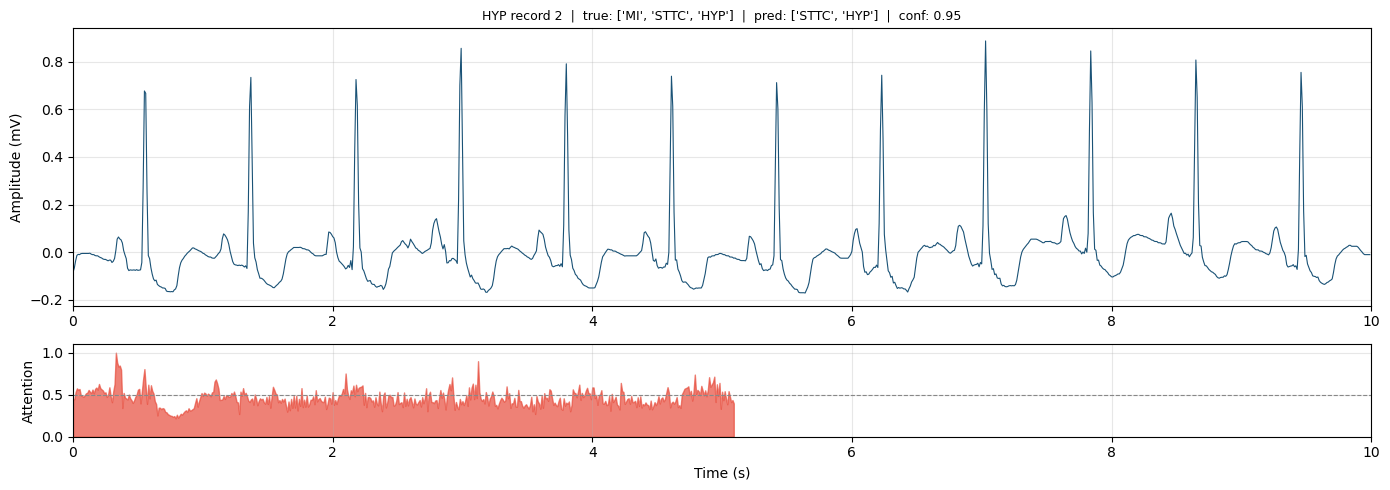

--- Record 2 narrative ---
The ECG analysis result indicates an MI (myocardial infarction) with ST-T changes and hypokinesia. The predicted class is STTC, which suggests a myocardial infarction. The confidence score is high at 0.95, indicating a high likelihood of this diagnosis based on the ECG findings.

The classification probability for STTC is 0.95, indicating a high chance of this finding being true. The prediction of hypokinesia is also high at 0.95, suggesting a high risk of this condition occurring.

The signal uncertainty is not computed, which could be due to the lack of sufficient data or the presence of other conditions that might affect the ECG readings. However, given the high confidence level and the high probability of STTC, it's reasonable to assume that this is likely the case.

Overall, the ECG analysis provides strong evidence for a MI diagnosis, but further investigation is needed to confirm this conclusion. It's important to note that this information should only

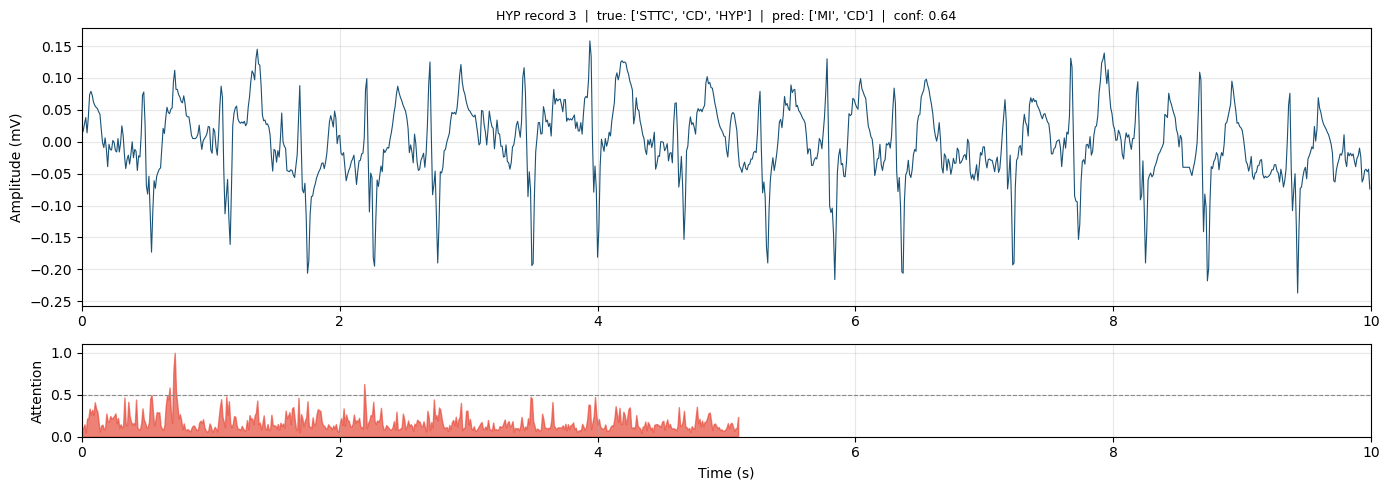

--- Record 3 narrative ---
The ECG analysis result indicates a patient with a history of hypertension and diabetes mellitus. The ECG shows a normal pattern in ST segment elevation, but there is an increased frequency of QRS complex tachycardia, which could be indicative of a heart rhythm disturbance. The predicted class is for myocardial infarction, with a probability of 0.64. However, the confidence score is low at 0.64, suggesting a high degree of uncertainty in predicting this outcome.

In terms of signal uncertainty, it's not possible to determine the exact value without further information or testing. The top salient leads are not included in the prediction as they were not observed during the ECG analysis. This suggests that the ECG may have missed some important cardiac events, possibly due to the patient's condition. 

Overall, the ECG analysis provides a preliminary diagnosis of a potentially life-threatening condition, but more detailed imaging studies and laboratory tests wo

In [10]:
CLASS = 'HYP'

for idx, row in enumerate(demo_records[CLASS]):
    sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    x = sig[:, LEAD_IDX].astype(np.float32)
    true_classes = [c for c, v in zip(SUPERCLASSES, row['label_vec']) if v == 1.0]

    result          = predict_single(model, x, device)
    positions, attn = model.get_attention_weights(x)
    prompt          = build_ecg_prompt(result, saliency=None,
                                       lead_names=LEAD_NAMES,
                                       true_classes=true_classes)
    narrative       = generate_explanation(prompt, qwen_model, qwen_tokenizer)

    fig, (ax_ecg, ax_attn) = plt.subplots(2, 1, figsize=(14, 5),
                                           gridspec_kw={'height_ratios': [3, 1]})
    title = (f'{CLASS} record {idx+1}  |  true: {true_classes}  |  '
             f'pred: {result["predicted_classes"]}  |  conf: {result["confidence_score"]:.2f}')
    plot_record(ax_ecg, ax_attn, x, positions, attn, title)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'{CLASS.lower()}_{idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

    safe_print(f'--- Record {idx+1} narrative ---\n{narrative}\n')
    narratives[CLASS].append({
        'record':       row['filename_lr'],
        'true_classes': true_classes,
        'predicted':    result['predicted_classes'],
        'confidence':   result['confidence_score'],
        'narrative':    narrative,
    })

## 11. Save outputs

In [11]:
with open(OUT_DIR / 'narratives.json', 'w') as f:
    json.dump(narratives, f, indent=2)

for cls, items in narratives.items():
    for item in items:
        assert len(item['narrative']) > 0, f'Empty narrative for {cls}: {item["record"]}'

print('Saved:')
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(Path(RESULTS_PATH))}  ({p.stat().st_size / 1024:.1f} KB)')
print('All 15 narratives verified non-empty.')

Saved:
  06_explainability\figures\cd_1.png  (159.6 KB)
  06_explainability\figures\cd_2.png  (162.8 KB)
  06_explainability\figures\cd_3.png  (146.6 KB)
  06_explainability\figures\hyp_1.png  (155.3 KB)
  06_explainability\figures\hyp_2.png  (156.2 KB)
  06_explainability\figures\hyp_3.png  (208.8 KB)
  06_explainability\figures\mi_1.png  (151.1 KB)
  06_explainability\figures\mi_2.png  (216.3 KB)
  06_explainability\figures\mi_3.png  (172.0 KB)
  06_explainability\figures\norm_1.png  (152.5 KB)
  06_explainability\figures\norm_2.png  (168.7 KB)
  06_explainability\figures\norm_3.png  (170.9 KB)
  06_explainability\figures\sttc_1.png  (156.6 KB)
  06_explainability\figures\sttc_2.png  (142.6 KB)
  06_explainability\figures\sttc_3.png  (182.5 KB)
  06_explainability\narratives.json  (15.6 KB)
All 15 narratives verified non-empty.


In [20]:
from collections import Counter
import json, wfdb, numpy as np
from pathlib import Path
from src.utils.config import CFG
from src.models.fcn_wang import FCNWang
from src.explainability.saliency import compute_saliency, top_salient_leads

# Load FCN-Wang checkpoint
RESULTS_PATH = CFG['paths']['results']
DATA_PATH    = CFG['data']['path']
ckpt_path    = str(Path(RESULTS_PATH) / 'fcn_wang_baseline' / 'checkpoint.pt')

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fcn      = FCNWang.load(ckpt_path)
fcn.to(device).eval()

# Load curated 200 records
curated_path = Path('../app/data/curated_200.json')
curated      = json.loads(curated_path.read_text())

LEAD_NAMES   = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
SUPERCLASSES = ['NORM','MI','STTC','CD','HYP']

# Compute top-3 salient leads per record per class
results = {cls: Counter() for cls in SUPERCLASSES}

for i, rec in enumerate(curated):
    sig, _ = wfdb.rdsamp(DATA_PATH + rec['filename_lr'])
    x = sig.T.astype(np.float32)   # (12, 1000)
    true_classes = [c for c, v in zip(SUPERCLASSES, rec['label_vec']) if v == 1.0]

    for cls in true_classes:
        cls_idx = SUPERCLASSES.index(cls)
        sal  = compute_saliency(fcn, x, cls_idx, device)
        top3 = top_salient_leads(sal, LEAD_NAMES, top_k=3)
        results[cls].update(top3)

    if (i + 1) % 20 == 0:
        print(f'  {i+1}/200 done')

print('\nTop-5 salient leads per class:')
for cls, counter in results.items():
    print(f'  {cls}: {counter.most_common(5)}')

FCN-Wang | Params: 309,765 total, 309,765 trainable (100.0%)
  20/200 done
  40/200 done
  60/200 done
  80/200 done
  100/200 done
  120/200 done
  140/200 done
  160/200 done
  180/200 done

Top-5 salient leads per class:
  NORM: [('II', 41), ('V1', 40), ('aVF', 20), ('V6', 12), ('III', 11)]
  MI: [('V1', 51), ('II', 36), ('III', 36), ('V2', 33), ('aVF', 33)]
  STTC: [('II', 60), ('V1', 59), ('V6', 45), ('aVR', 22), ('III', 20)]
  CD: [('V1', 69), ('II', 58), ('aVF', 29), ('V2', 20), ('III', 13)]
  HYP: [('V1', 57), ('II', 45), ('V6', 27), ('III', 27), ('aVR', 5)]


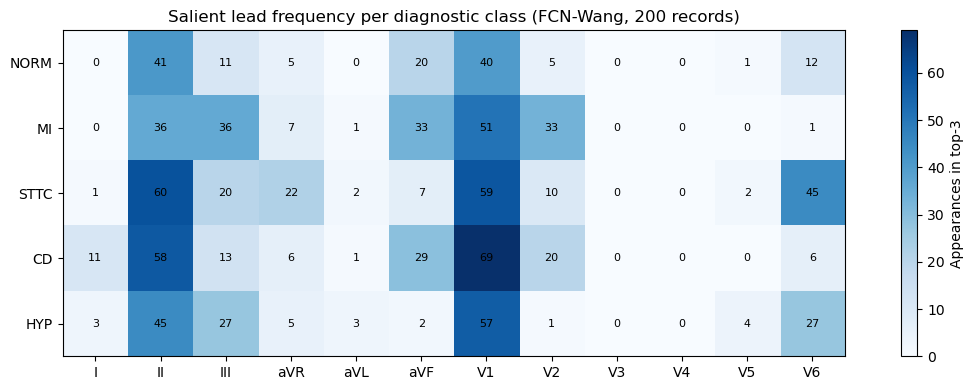

In [22]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
matrix = np.zeros((5, 12))
for i, cls in enumerate(classes):
    for j, lead in enumerate(LEAD_NAMES):
        matrix[i, j] = results[cls].get(lead, 0)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(matrix, cmap='Blues')
ax.set_xticks(range(12)); ax.set_xticklabels(LEAD_NAMES)
ax.set_yticks(range(5));  ax.set_yticklabels(classes)
for i in range(5):
    for j in range(12):
        ax.text(j, i, int(matrix[i,j]), ha='center', va='center', fontsize=8)
plt.colorbar(im, label='Appearances in top-3')
plt.title('Salient lead frequency per diagnostic class (FCN-Wang, 200 records)')
plt.tight_layout()
plt.savefig('../results/06_explainability/lead_saliency_heatmap.png', dpi=150)
plt.show()